In [1]:
import re
import pandas as pd
from itertools import combinations
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import itertools
import tracemalloc
import time
from collections import Counter
import matplotlib.ticker as ticker
import random
import statistics
from memory_profiler import memory_usage
from math import comb


/Users/bercaakbayir/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
from src.helper import kaggle_data_handler, print_results
from src.algorithms import (triangular_matrix_method, triples_method, 
                            apriori, multihash_algorithm, son_algorithm, son_mapreduce)

In [3]:
kaggle_link = 'https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows'

In [4]:
df = kaggle_data_handler(kaggle_link)

In [5]:
df

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,https://m.media-amazon.com/images/M/MV5BNGEwMT...,Breakfast at Tiffany's,1961,A,115 min,"Comedy, Drama, Romance",7.6,A young New York socialite becomes interested ...,76.0,Blake Edwards,Audrey Hepburn,George Peppard,Patricia Neal,Buddy Ebsen,166544,NaN
996,https://m.media-amazon.com/images/M/MV5BODk3Yj...,Giant,1956,G,201 min,"Drama, Western",7.6,Sprawling epic covering the life of a Texas ca...,84.0,George Stevens,Elizabeth Taylor,Rock Hudson,James Dean,Carroll Baker,34075,NaN
997,https://m.media-amazon.com/images/M/MV5BM2U3Yz...,From Here to Eternity,1953,Passed,118 min,"Drama, Romance, War",7.6,"In Hawaii in 1941, a private is cruelly punish...",85.0,Fred Zinnemann,Burt Lancaster,Montgomery Clift,Deborah Kerr,Donna Reed,43374,"30,500,000"
998,https://m.media-amazon.com/images/M/MV5BZTBmMj...,Lifeboat,1944,NaN,97 min,"Drama, War",7.6,Several survivors of a torpedoed merchant ship...,78.0,Alfred Hitchcock,Tallulah Bankhead,John Hodiak,Walter Slezak,William Bendix,26471,NaN


In [6]:
df.describe()

,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [8]:
df.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

In [9]:
df[['Series_Title', 'Star1', 'Star2', 'Star3', 'Star4']]

,Series_Title,Star1,Star2,Star3,Star4
0,The Shawshank Redemption,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler
1,The Godfather,Marlon Brando,Al Pacino,James Caan,Diane Keaton
2,The Dark Knight,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine
3,The Godfather: Part II,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton
4,12 Angry Men,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler
...,...,...,...,...,...
995,Breakfast at Tiffany's,Audrey Hepburn,George Peppard,Patricia Neal,Buddy Ebsen
996,Giant,Elizabeth Taylor,Rock Hudson,James Dean,Carroll Baker
997,From Here to Eternity,Burt Lancaster,Montgomery Clift,Deborah Kerr,Donna Reed
998,Lifeboat,Tallulah Bankhead,John Hodiak,Walter Slezak,William Bendix


# Basket Data Analysis

In [10]:
null_pct = df.isnull().sum() / len(df) * 100

blank_pct = df.apply(lambda col: col.astype(str).str.strip().eq('').sum() / len(df) * 100)

pd.DataFrame({'null_%': null_pct, 'blank_%': blank_pct}).round(2)

,null_%,blank_%
Poster_Link,0.0,0.0
Series_Title,0.0,0.0
Released_Year,0.0,0.0
Certificate,10.1,0.0
Runtime,0.0,0.0
Genre,0.0,0.0
IMDB_Rating,0.0,0.0
Overview,0.0,0.0
Meta_score,15.7,0.0
Director,0.0,0.0


In [11]:
def normalize_name(name: str) -> str:
    name = name.strip()
    name = re.sub(r'\s+', ' ', name)         
    name = name.title()                       
    name = re.sub(r"'([A-Z])", lambda m: "'" + m.group(1), name)
    return name


def normalize_baskets(baskets: list[set]) -> list[set]:
    return [
        {normalize_name(actor) for actor in basket}
        for basket in baskets
    ]

In [12]:
actor_cols = ['Star1', 'Star2', 'Star3', 'Star4']
df[actor_cols] = df[actor_cols].map(
    lambda x: normalize_name(x) if pd.notna(x) else x
)

In [13]:
def sample_baskets(df, proportion, seed=42):
    basket_def = df[["Star1","Star2","Star3","Star4"]].values.tolist()
    
    clean_baskets = []
    duplicate_count = 0
    for i, row in enumerate(basket_def):
        unique_actors = list(dict.fromkeys(a for a in row if pd.notna(a)))  # preserve order, drop NaN
        if len(unique_actors) < len([a for a in row if pd.notna(a)]):
            duplicate_count += 1
            print(f"  [WARNING] Movie index {i} has duplicate actors: {row}")
        clean_baskets.append(set(unique_actors))
    
    if duplicate_count == 0:
        print("[OK] No duplicate actors found within any movie.")
    else:
        print(f"\n[WARNING] {duplicate_count} movie(s) had duplicate actors — duplicates removed.")

    sample_size = int(len(clean_baskets) * proportion)
    rng = random.Random(seed)
    sampled_baskets = rng.sample(clean_baskets, sample_size)
    return sampled_baskets

In [14]:
PROPORTION = 1.0 
SUPPORT_LEVEL = 5

In [15]:
baskets = sample_baskets(df, PROPORTION)
print(f"Basket count: {len(baskets)}")

  [WARNING] Movie index 120 has duplicate actors: ['Gene Kelly', 'Gene Kelly', "Donald O'Connor", 'Debbie Reynolds']
  [WARNING] Movie index 320 has duplicate actors: ['Buster Keaton', 'Buster Keaton', 'Marion Mack', 'Glen Cavender']
  [WARNING] Movie index 727 has duplicate actors: ['Taika Waititi', 'Jemaine Clement', 'Taika Waititi', 'Cori Gonzalez-Macuer']
  [WARNING] Movie index 815 has duplicate actors: ['Massimo Troisi', 'Massimo Troisi', 'Philippe Noiret', 'Maria Grazia Cucinotta']

[WARNING] 4 movie(s) had duplicate actors — duplicates removed.
Basket count: 1000


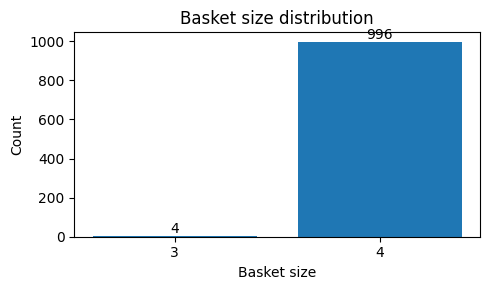

3:4, 4:996


In [16]:
sizes = [len(b) for b in baskets]
counts = Counter(sizes)
fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(counts.keys(), counts.values())
ax.bar_label(bars) 
ax.set_xlabel('Basket size')
ax.set_ylabel('Count')
ax.set_title('Basket size distribution')
ax.set_xticks(list(counts.keys()))
plt.tight_layout()
plt.show()

print(', '.join(f'{k}:{v}' for k, v in sorted(counts.items())))

In [29]:
df[df.apply(lambda row: len(set([row['Star1'], row['Star2'], row['Star3'], row['Star4']])) < 4, axis=1)][['Star1','Star2','Star3','Star4', 'Series_Title']]


,Star1,Star2,Star3,Star4,Series_Title
120,Gene Kelly,Gene Kelly,Donald O'Connor,Debbie Reynolds,Singin' in the Rain
320,Buster Keaton,Buster Keaton,Marion Mack,Glen Cavender,The General
727,Taika Waititi,Jemaine Clement,Taika Waititi,Cori Gonzalez-Macuer,What We Do in the Shadows
815,Massimo Troisi,Massimo Troisi,Philippe Noiret,Maria Grazia Cucinotta,Il postino


In [18]:
print(f"There are {df['Director'].nunique()} unique directors in top 1000 movies.")

There are 548 unique directors in top 1000 movies.


In [19]:
all_actors  = pd.concat([df['Star1'], df['Star2'], df['Star3'], df['Star4']])
actor_freq  = all_actors.value_counts()

In [20]:
observed_pairs = set()
for _, row in df[['Star1', 'Star2', 'Star3', 'Star4']].iterrows():
    actors = [a for a in row if pd.notna(a)]
    for pair in combinations(sorted(actors), 2):
        observed_pairs.add(pair)

N_actors      = actor_freq.shape[0]          
N_possible    = comb(N_actors, 2)            
N_observed    = len(observed_pairs)
sparsity      = 1 - (N_observed / N_possible)
coverage      = N_observed / N_possible

In [21]:
print("── Sparsity / Coverage ──")
print(f"Unique actors (N)             : {N_actors}")
print(f"Possible pairs  C(N,2)        : {N_possible:,}")
print(f"Observed co-occurring pairs   : {N_observed:,}")
print(f"Coverage                      : {coverage * 100:.4f}%")
print(f"Sparsity                      : {sparsity * 100:.4f}%")

── Sparsity / Coverage ──
Unique actors (N)             : 2709
Possible pairs  C(N,2)        : 3,667,986
Observed co-occurring pairs   : 5,837
Coverage                      : 0.1591%
Sparsity                      : 99.8409%


In [22]:
pairs_per_movie = df[['Star1', 'Star2', 'Star3', 'Star4']].apply(
    lambda row: len(list(combinations([a for a in row if pd.notna(a)], 2))),
    axis=1
)
print(f"\nPairs per movie (always 4 stars → 6 pairs): {pairs_per_movie.unique().tolist()}")
print(f"Total (movie, pair) observations          : {pairs_per_movie.sum():,}")


Pairs per movie (always 4 stars → 6 pairs): [6]
Total (movie, pair) observations          : 6,000


In [23]:
print("\n── Top N Movies and Occured Pairs ──")
total_movies = len(df)
for min_count in [2, 3, 4, 5, 6]:
    pct = min_count / total_movies * 100
    qualifying = sum(1 for c in pair_counts.values() if c >= min_count)
    print(f"  count ≥ {min_count} ({pct}%)  →  {qualifying} pairs qualify")



── Top N Movies and Occured Pairs ──


NameError: name 'pair_counts' is not defined

In [ ]:
pair_counts = Counter()
for _, row in df[['Star1', 'Star2', 'Star3', 'Star4']].iterrows():
    actors = [a for a in row if pd.notna(a)]
    for pair in combinations(sorted(actors), 2):
        pair_counts[pair] += 1

In [ ]:
genre_actors = defaultdict(set)
genre_movie_counts = defaultdict(int)

for _, row in df.iterrows():
    genres = [g.strip() for g in row['Genre'].split(',')]
    actors = [row[c] for c in ['Star1','Star2','Star3','Star4'] if pd.notna(row[c])]
    for genre in genres:
        genre_actors[genre].update(actors)
        genre_movie_counts[genre] += 1

In [ ]:
genre_actor_df = (
    pd.DataFrame([
        {
            'Genre'        : genre,
            'Unique_Actors': len(actors),
            'Movie_Count'  : genre_movie_counts[genre],
        }
        for genre, actors in genre_actors.items()
    ])
    .assign(Actors_per_Movie=lambda x: (x['Unique_Actors'] / x['Movie_Count']).round(2))
    .sort_values('Unique_Actors', ascending=False)
    .reset_index(drop=True)
)

In [ ]:
print(f"Unique genres found : {len(genre_actor_df)}")
print(f"\nFull Summary (sorted by Unique Actors):")
print(genre_actor_df.to_string(index=False))

In [ ]:
plot_df = genre_actor_df.sort_values('Unique_Actors', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(plot_df['Genre'], plot_df['Unique_Actors'], color='steelblue')

for bar, val in zip(bars, plot_df['Unique_Actors']):
    ax.text(
        bar.get_width() + 2,          
        bar.get_y() + bar.get_height() / 2, 
        str(val),
        va='center', ha='left', fontsize=9
    )

ax.set_xlabel('Unique Actors')
ax.set_title('Unique Actors per Genre')
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_xlim(0, plot_df['Unique_Actors'].max() * 1.1)  

plt.tight_layout()
plt.show()

In [ ]:
plot_df2 = genre_actor_df.sort_values('Movie_Count', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(plot_df2['Genre'], plot_df2['Movie_Count'], color='coral')

for bar, val in zip(bars, plot_df2['Movie_Count']):
    ax.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va='center', ha='left', fontsize=9
    )

ax.set_xlabel('Movie Count')
ax.set_title('Most Frequent Genres')
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_xlim(0, plot_df2['Movie_Count'].max() * 1.1)

plt.tight_layout()
plt.show()

In [ ]:
director_counts = df['Director'].value_counts().head(20)
plot_df3 = director_counts.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.barh(plot_df3.index, plot_df3.values, color='mediumseagreen')

for bar, val in zip(bars, plot_df3.values):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va='center', ha='left', fontsize=9
    )

ax.set_xlabel('Movie Count')
ax.set_title('Top 20 Most Frequent Directors')
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_xlim(0, plot_df3.values.max() * 1.15)

plt.tight_layout()
plt.show()

# Support

In [ ]:
def get_itemset_support(baskets, metadata, k=1, top_n=None, genre=None):
    """
    Parameters:
        baskets   : list of lists (each basket is [Star1, Star2, Star3, Star4])
        metadata  : list of dicts with at least a 'Genre' key (parallel to baskets)
        k         : int — itemset size (1=singleton, 2=doubleton, 3=tripleton, ...)
        top_n     : int or None — return only top N items by support
        genre     : str or None — filter to baskets where genre appears in 'Genre'
    """
    itemset_support = defaultdict(int)

    for basket, meta in zip(baskets, metadata):
        if genre is not None:
            film_genres = [g.strip() for g in meta['Genre'].split(',')]
            if genre not in film_genres:
                continue
        for itemset in combinations(sorted(basket), k):
            itemset_support[itemset] += 1

    itemset_support = dict(
        sorted(itemset_support.items(), key=lambda x: x[1], reverse=True)
    )

    if top_n is not None:
        itemset_support = dict(list(itemset_support.items())[:top_n])

    return itemset_support



In [ ]:
top_n = 5
genre = None
metadata = df[['Genre']].to_dict(orient='records')

singleton_support  = get_itemset_support(baskets, metadata, k=1, top_n=top_n, genre=genre)
doubleton_support  = get_itemset_support(baskets, metadata, k=2, top_n=top_n, genre=genre)
tripleton_support  = get_itemset_support(baskets, metadata, k=3, top_n=top_n, genre=genre)

for label, result in [("Singleton", singleton_support),
                      ("Doubleton", doubleton_support),
                      ("Tripleton", tripleton_support)]:
    print(f"\n{label} Support (genre={'All' if genre is None else genre}, top_n={top_n}):")
    for itemset, support in result.items():
        print(f"  {itemset}: {support}")

# Confidence 

In [ ]:
def confidence(lhs, rhs, baskets, verbose=True):
    lhs = set(lhs)
    rhs = set(rhs)
    union = lhs | rhs

    support_lhs   = sum(1 for b in baskets if lhs.issubset(b))
    support_union = sum(1 for b in baskets if union.issubset(b))

    if support_lhs == 0:
        return None

    conf = support_union / support_lhs

    if verbose:
        print(f"  support({lhs}) = {support_lhs}")
        print(f"  support({lhs | rhs}) = {support_union}")
        print(f"  confidence({lhs} → {rhs}) = {support_union}/{support_lhs} = {conf:.4f}")

    return conf

In [ ]:
confidence({"Christian Bale"}, {"Robert De Niro"}, baskets)


Interpretation : Christian Bale appears in 11 different movies. But Robert De Niro does not appear in any movie that Christian Bale appeared. Therefore, Confidence score is 0/11 = 0

In [ ]:
confidence({"Emma Watson"}, {"Rupert Grint"}, baskets)


Interpretation : Emma Watson appears in 7 diferent movies. Rubert Grint appears in 5 movies among those 7 movies that Emma Watson appeared in. Therefore, confidence level is 5/7 = 0.71

In [ ]:
confidence({"Orlando Bloom"}, {"Elijah Wood"}, baskets)


Interpretation : Orlando Bloom appears in 4 movies. Elija Wood appears in 3 movies among those 4 movies that Orlando Bloom appeared in.Therefore, confidence level is 3/4 = 0.75

# Interest

In [ ]:
def interest(lhs, rhs, baskets):
    """
    lhs: list or set of items (left-hand side)
    rhs: list or set of items (right-hand side)
    """
    rhs = set(rhs)

    conf = confidence(lhs, rhs, baskets)

    if conf is None:
        return None

    support_rhs = sum(1 for b in baskets if rhs.issubset(b))
    prob_rhs = support_rhs / len(baskets)

    interest_score = conf - prob_rhs

    print(f"  P({rhs}) = {support_rhs}/{len(baskets)} = {prob_rhs:.4f}")
    print(f"  interest({set(lhs)} → {rhs}) = {conf:.4f} - {prob_rhs:.4f} = {interest_score:.4f}")
    return interest_score

In [ ]:
interest({"Orlando Bloom"}, {"Elijah Wood"}, baskets)

Confidence level is 0.75 for Orlando Bloom -> Elijah Wood.

Elija Wood appears in 3 movies among all 1000 movies in dataset -> 3/1000 = 0.003

Therefore, interest level is ;

0.75 - 0.003 = 0.747

So, presence of Orlando Bloom encourages Elijah Wood to be in that movie.

# A-Priori Algorithm

In [ ]:
apriori_results = apriori(baskets, support_threshold=SUPPORT_LEVEL)

In [ ]:
apriori_results

# The Multihash Algorithm

In [ ]:
_, result_mh = multihash_algorithm(baskets, support=SUPPORT_LEVEL)

In [ ]:
result_mh

# The SON Algorithm (Using Multihash)

In [ ]:
result_son = son_algorithm(
        baskets,
        support_threshold=SUPPORT_LEVEL,
        num_chunks=2,
        num_hash_tables=2,
    )

In [ ]:
result_son

# The SON Algorithm Implementation with MapReduce

In [ ]:
result_son_mp = son_mapreduce(
    baskets=baskets,
    support_threshold=SUPPORT_LEVEL,
    num_chunks=2,
    num_hash_tables=2,
    num_buckets=None,
)

In [ ]:
result_son_mp

# Algorithm Benchmark

In [ ]:
def _timed(fn):
    t0 = time.perf_counter()
    result = fn()
    t1 = time.perf_counter()
    return t0, t1, result
def benchmark(
    baskets: list[set],
    sample_fractions: list[float] = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0],
    support: int = 3,
    n_trials: int = 5,
    seed: int = 42,
) -> pd.DataFrame:
    rng = random.Random(seed)

    algorithms = {
        "apriori":       lambda b, s: apriori(b, s),
        "multihash":     lambda b, s: multihash_algorithm(b, s),
        "son":           lambda b, s: son_algorithm(b, s),
        "son_mapreduce": lambda b, s: son_mapreduce(b, s),
    }

    records = []

    for fraction in sample_fractions:
        n = max(1, int(len(baskets) * fraction))
        sample = rng.sample(baskets, n)

        for algo_name, algo_fn in algorithms.items():
            runtimes, mems = [], []

            for _ in range(n_trials):
                try:
                    mem, (t0, t1, _) = memory_usage(
                        (_timed, (lambda: algo_fn(sample, support),)),
                        retval=True,
                        interval=0.01,
                        include_children=True,
                    )
                    runtimes.append(t1 - t0)
                    mems.append(max(mem) - mem[0])
                except Exception as e:
                    runtimes, mems = None, None
                    error = str(e)
                    break

            if runtimes is None:
                records.append({
                    "algorithm": algo_name, "sample_fraction": fraction,
                    "sample_size": n, "runtime_mean_s": float("nan"),
                    "runtime_std_s": float("nan"), "peak_memory_mib": float("nan"),
                    "error": error,
                })
            else:
                records.append({
                    "algorithm":       algo_name,
                    "sample_fraction": fraction,
                    "sample_size":     n,
                    "runtime_mean_s":  round(statistics.mean(runtimes), 4),
                    "runtime_std_s":   round(statistics.stdev(runtimes) if n_trials > 1 else 0.0, 4),
                    "peak_memory_mib": round(max(mems), 3),
                })

    return (
        pd.DataFrame(records)
        .sort_values(["sample_fraction", "algorithm"])
        .reset_index(drop=True)
    )

In [ ]:
def plot_benchmark(df: pd.DataFrame) -> None:
    algorithms = df["algorithm"].unique()

    colors  = {"apriori": "#378ADD", "multihash": "#1D9E75", "son": "#D85A30", "son_mapreduce": "#9B59B6"}
    markers = {"apriori": "o",       "multihash": "s",       "son": "^",       "son_mapreduce": "*"}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor("#FAFAFA")

    def style_ax(ax, title, ylabel):
        ax.set_facecolor("#FAFAFA")
        ax.set_title(title, fontsize=13, fontweight="500", pad=12, color="#2C2C2A")
        ax.set_xlabel("Dataset size (baskets)", fontsize=11, color="#5F5E5A")
        ax.set_ylabel(ylabel, fontsize=11, color="#5F5E5A")
        ax.tick_params(colors="#888780", labelsize=10)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.3g}"))
        for spine in ax.spines.values():
            spine.set_edgecolor("#D3D1C7")
            spine.set_linewidth(0.8)
        ax.grid(axis="y", color="#D3D1C7", linewidth=0.6, linestyle="--", alpha=0.7)
        ax.grid(axis="x", color="#D3D1C7", linewidth=0.4, linestyle=":",  alpha=0.5)
        ax.set_axisbelow(True)
        ax.legend(frameon=True, framealpha=0.9, edgecolor="#D3D1C7", fontsize=10).get_frame().set_linewidth(0.6)

    for algo in algorithms:
        subset = df[df["algorithm"] == algo].sort_values("sample_size")
        kw = dict(label=algo, color=colors.get(algo, "#888"), marker=markers.get(algo, "o"),
                  linewidth=2, markersize=6, markeredgewidth=1.5, markeredgecolor="white")

        axes[0].plot(subset["sample_size"], subset["runtime_mean_s"], **kw)
        axes[0].fill_between(subset["sample_size"],
                             subset["runtime_mean_s"] - subset["runtime_std_s"],
                             subset["runtime_mean_s"] + subset["runtime_std_s"],
                             color=colors.get(algo, "#888"), alpha=0.12)

        axes[1].plot(subset["sample_size"], subset["peak_memory_mib"], **kw)

    style_ax(axes[0], "Runtime vs dataset size", "Runtime (s)")
    style_ax(axes[1], "Memory vs dataset size",  "Peak memory (MiB)")

    plt.tight_layout(pad=2.0)
    plt.show()

In [ ]:
algorithm_evaluation = benchmark(baskets)

In [ ]:
algorithm_evaluation

In [ ]:
plot_benchmark(algorithm_evaluation)
